# Cardiac DTI — Stanford Myofiber Mobility Dataset
## Complete Analysis Pipeline for Paper Submission

**Papers generated from this notebook:**
- Paper 1: *Phase-Resolved Myofiber Mobility Quantified by cDTI: An Open-Source Python Framework*
- Paper 2: *3D LV Microstructural Modelling from cDTI with Deep Learning Reconstruction*

### Exact dataset structure confirmed by inspection:
```
DataBase_Myofiber_Mobility_2020/
  Vol3/ Vol4/ Vol5/ Vol6/ Vol7/ Vol9/ Vol10/ Vol11/ Vol12/
    └── Diast/ Syst1/ Syst2/
          └── Maps/
                ├── DTI.mat         → FA(256,208), MD, EigVector(256,208,3,3), EigValue(256,208,3)
                ├── HA2.mat         → HA_filter2(256,208)°, E2A(256,208)°, TRA2
                ├── ROI.mat         → LV_Mask(256,208), Mask_AHA(256,208,6), P_Endo/P_Epi(200,2)
                ├── ADC.mat         → ADC(256,208)
                ├── Mask.mat        → Mask(256,208)
                ├── Average.mat     → Dcm(256,208,2,12) mean DWI
                ├── RAW.mat         → Dcm(128,104,2,12,8) raw DWI
                ├── HA_Observ*.mat  → MATLAB v7.3 HDF5 (need h5py)
                └── ROI_Observ*.mat → LV_Mask, Mask_AHA, P_Endo, P_Epi
```
**Key insight**: Each phase folder contains ONE 2D short-axis slice (256×208 px).  
3D models are built by stacking phases (Diast → Syst1 → Syst2) using P_Endo/P_Epi contours.


## 0. Configuration — SET YOUR DATA PATH HERE

In [1]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.ndimage import gaussian_filter, distance_transform_edt
from scipy.spatial import cKDTree
from scipy import stats
from skimage import measure
from pathlib import Path
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

try:
    import pingouin as pg
    HAS_PINGOUIN = True
except ImportError:
    HAS_PINGOUIN = False
    print('pingouin not found — ICC will use manual calculation')

# ─────────────────────────────────────────────────────────────────────
# ▶▶▶  SET THIS TO YOUR DATASET ROOT  ◀◀◀
DATA_DIR = Path('./DataBase_Myofiber_Mobility_2020')
OUT_DIR  = Path('./figures')   # output directory for all figures
OUT_DIR.mkdir(exist_ok=True)
# ─────────────────────────────────────────────────────────────────────

# Subjects present (Vol8 absent in dataset)
SUBJECTS = ['Vol3','Vol4','Vol5','Vol6','Vol7','Vol9','Vol10','Vol11','Vol12']
PHASES   = ['Diast','Syst1','Syst2']
PHASE_Z  = {'Diast': 0.0, 'Syst1': 10.0, 'Syst2': 20.0}  # mm spacing for 3D stack

# AHA segment labels and colours
AHA_NAMES  = ['Anterior','Anteroseptal','Inferoseptal','Inferior','Inferolateral','Anterolateral']
AHA_COLORS = ['#E63946','#F4A261','#2A9D8F','#457B9D','#9B5DE5','#F72585']

# Colormaps
CMAP_HA = cm.RdBu_r;  NORM_HA = Normalize(-90, 90)
CMAP_FA = cm.magma;   NORM_FA = Normalize(0,  0.6)
CMAP_MD = cm.viridis; NORM_MD = Normalize(0.5, 3.0)

print(f'Data root : {DATA_DIR.resolve()}')
print(f'Output dir: {OUT_DIR.resolve()}')
print(f'Subjects  : {SUBJECTS}')
print(f'Phases    : {PHASES}')

Data root : /Users/user/Downloads/DataBase_Myofiber_Mobility_2020
Output dir: /Users/user/Downloads/figures
Subjects  : ['Vol3', 'Vol4', 'Vol5', 'Vol6', 'Vol7', 'Vol9', 'Vol10', 'Vol11', 'Vol12']
Phases    : ['Diast', 'Syst1', 'Syst2']


## 1. Data Loader — matches exact .mat variable names

In [2]:
def load_phase(subject, phase):
    """
    Load all .mat maps for one subject/phase.

    File → variable mapping (confirmed by direct inspection):
      DTI.mat   : FA(256,208), MD, EigVector(256,208,3,3), EigValue(256,208,3)
                  EigVector[:,:,i,:] = i-th eigenvector (0=primary)
                  EigValue[:,:,0] = λ1 ≥ λ2 ≥ λ3 (already descending)
      HA2.mat   : HA_filter2 = best helix angle map (most valid pixels)
                  E2A = sheetlet angle, TRA2 = transverse angle
      ROI.mat   : LV_Mask(256,208 uint8), Mask_AHA(256,208,6 uint8)
                  P_Endo(200,2), P_Epi(200,2) = contour coordinates
                  Mask_Depth(256,208) = pre-computed transmural depth [0,1]
      ADC.mat   : ADC(256,208) apparent diffusion coefficient
      ROI_Observ*.mat: same structure as ROI.mat (observer reproducibility)
    """
    maps_dir = DATA_DIR / subject / phase / 'Maps'
    if not maps_dir.exists():
        return None

    def mat(fname, key):
        """Load one variable from a .mat file."""
        try:
            return sio.loadmat(str(maps_dir / fname), squeeze_me=True)[key]
        except Exception:
            return None

    dti_mat = sio.loadmat(str(maps_dir / 'DTI.mat'), squeeze_me=True)
    ha2_mat = sio.loadmat(str(maps_dir / 'HA2.mat'), squeeze_me=True)
    roi_mat = sio.loadmat(str(maps_dir / 'ROI.mat'), squeeze_me=True)

    out = {
        'subject': subject,
        'phase'  : phase,
        # ── DTI maps ──────────────────────────────────────────────────
        'FA'     : dti_mat['FA'].astype(float),           # (256,208)
        'MD'     : dti_mat['MD'].astype(float),           # (256,208) mm²/s
        'evec'   : dti_mat['EigVector'].astype(float),    # (256,208,3,3)
        'eval'   : dti_mat['EigValue'].astype(float),     # (256,208,3) λ1≥λ2≥λ3
        'tensor' : dti_mat['Tensor'].astype(float),       # (256,208,6) Voigt
        # ── HA maps ───────────────────────────────────────────────────
        'HA'     : ha2_mat['HA_filter2'].astype(float),   # (256,208) degrees
        'E2A'    : ha2_mat['E2A'].astype(float),          # (256,208) sheetlet angle
        'TRA'    : ha2_mat['TRA2'].astype(float),         # (256,208) transverse angle
        'E1'     : ha2_mat['EigVect1'].astype(float),     # (256,208,3)
        # ── ROI / segmentation ────────────────────────────────────────
        'mask'   : roi_mat['LV_Mask'].astype(bool),       # (256,208)
        'aha'    : roi_mat['Mask_AHA'].astype(np.uint8),  # (256,208,6) AHA segments
        'depth'  : roi_mat['Mask_Depth'].astype(float),   # (256,208) transmural depth
        'endo'   : roi_mat['P_Endo'].astype(float),       # (200,2) x,y pixels
        'epi'    : roi_mat['P_Epi'].astype(float),        # (200,2) x,y pixels
        # ── ADC ───────────────────────────────────────────────────────
        'ADC'    : mat('ADC.mat', 'ADC'),                  # (256,208)
    }

    # Observer reproducibility ROIs (scipy loadmat, not HDF5)
    for tag, fname in [('roi_obs1_m2','ROI_Observ1_Meas2.mat'),
                       ('roi_obs2_m1','ROI_Observ2_Meas1.mat'),
                       ('roi_obs2_m2','ROI_Observ2_Meas2.mat')]:
        try:
            r = sio.loadmat(str(maps_dir / fname), squeeze_me=True)
            out[tag] = r['LV_Mask'].astype(bool)
        except Exception:
            out[tag] = None

    return out


# ── Load entire dataset ───────────────────────────────────────────────
dataset = {}
for subj in SUBJECTS:
    dataset[subj] = {}
    for phase in PHASES:
        d = load_phase(subj, phase)
        if d is not None:
            dataset[subj][phase] = d
            m = d['mask']
            fa_m = d['FA'][m]
            ha_m = d['HA'][m]; ha_m = ha_m[~np.isnan(ha_m)]
            print(f'  ✓ {subj}/{phase}  mask={m.sum()}px  '
                  f'FA={fa_m.mean():.3f}  HA={ha_m.mean():.1f}°±{ha_m.std():.1f}°')
        else:
            print(f'  ✗ {subj}/{phase}  NOT FOUND')

n_loaded = sum(len(v) for v in dataset.values())
print(f'\nLoaded: {len([s for s in dataset if dataset[s]])}/{len(SUBJECTS)} subjects, '
      f'{n_loaded} total phase-datasets')

  ✓ Vol3/Diast  mask=2231px  FA=0.335  HA=-2.8°±38.7°
  ✓ Vol3/Syst1  mask=1975px  FA=0.329  HA=-5.7°±36.0°
  ✓ Vol3/Syst2  mask=2008px  FA=0.312  HA=4.1°±37.8°
  ✓ Vol4/Diast  mask=1883px  FA=0.356  HA=-3.7°±40.5°
  ✓ Vol4/Syst1  mask=1928px  FA=0.413  HA=2.3°±33.2°
  ✓ Vol4/Syst2  mask=2520px  FA=0.341  HA=1.1°±40.1°
  ✗ Vol5/Diast  NOT FOUND
  ✓ Vol5/Syst1  mask=2867px  FA=0.374  HA=12.4°±38.0°
  ✓ Vol5/Syst2  mask=3140px  FA=0.363  HA=12.9°±36.6°
  ✓ Vol6/Diast  mask=3350px  FA=0.382  HA=2.7°±34.0°
  ✓ Vol6/Syst1  mask=3078px  FA=0.426  HA=4.2°±34.4°
  ✓ Vol6/Syst2  mask=3268px  FA=0.374  HA=-1.5°±35.3°
  ✓ Vol7/Diast  mask=3490px  FA=0.346  HA=3.9°±32.6°
  ✓ Vol7/Syst1  mask=3247px  FA=0.368  HA=2.6°±31.6°
  ✓ Vol7/Syst2  mask=3834px  FA=0.346  HA=-0.9°±42.0°
  ✗ Vol9/Diast  NOT FOUND
  ✓ Vol9/Syst1  mask=1998px  FA=0.332  HA=0.6°±34.2°
  ✓ Vol9/Syst2  mask=2493px  FA=0.343  HA=0.5°±35.7°
  ✗ Vol10/Diast  NOT FOUND
  ✓ Vol10/Syst1  mask=2044px  FA=0.329  HA=-0.3°±35.3°
  ✓ Vol10/S

## 2. Core Analysis Functions

In [3]:
def transmural_profile(ha, mask, depth, n_bins=12):
    """
    Compute mean HA ± SD per transmural bin using pre-computed Mask_Depth.
    depth=0 → endocardium, depth=1 → epicardium.
    """
    m = mask & ~np.isnan(ha) & ~np.isnan(depth) & (depth > 0)
    if m.sum() < n_bins * 3:
        return np.full(n_bins, np.nan), np.full(n_bins, np.nan), np.full(n_bins, np.nan)
    d = depth[m]; h = ha[m]
    bins = np.linspace(0, 1, n_bins + 1)
    mid  = 0.5 * (bins[:-1] + bins[1:])
    hm   = np.array([h[(d>=bins[i])&(d<bins[i+1])].mean()
                     if ((d>=bins[i])&(d<bins[i+1])).sum() > 2 else np.nan
                     for i in range(n_bins)])
    hs   = np.array([h[(d>=bins[i])&(d<bins[i+1])].std()
                     if ((d>=bins[i])&(d<bins[i+1])).sum() > 2 else np.nan
                     for i in range(n_bins)])
    return mid, hm, hs


def myofiber_mobility(d_diast, d_syst):
    """
    Compute phase-resolved myofiber mobility ΔHA = HA_syst − HA_diast.
    Returns: dHA map, mean|ΔHA|, std|ΔHA|, dE2A map, mean|ΔE2A|
    """
    combined = d_diast['mask'] & d_syst['mask']
    dHA  = d_syst['HA']  - d_diast['HA']
    dE2A = d_syst['E2A'] - d_diast['E2A']
    valid = combined & ~np.isnan(dHA)
    abs_dHA  = np.abs(dHA[valid])
    abs_dE2A = np.abs(dE2A[combined & ~np.isnan(dE2A)])
    return {
        'dHA_map'    : np.where(combined, dHA, np.nan),
        'dE2A_map'   : np.where(combined, dE2A, np.nan),
        'mob_ha_mean': abs_dHA.mean(),
        'mob_ha_std' : abs_dHA.std(),
        'mob_e2a_mean':abs_dE2A.mean(),
        'combined'   : combined,
    }


def build_3d_mesh(phases_data, spacing_mm=(0.8, 0.8, 10.0)):
    """
    Build 3D LV surface mesh by stacking 2D masks from multiple phases.
    Maps FA, HA onto mesh vertices via nearest-neighbour.

    phases_data: list of dicts in phase order [Diast, Syst1, Syst2]
    Returns: verts, faces, vert_ha, vert_fa
    """
    masks = [d['mask'] for d in phases_data]
    has   = [d['HA']   for d in phases_data]
    fas   = [d['FA']   for d in phases_data]

    stk_mask = np.stack(masks, axis=2).astype(np.uint8)
    stk_ha   = np.stack(has,   axis=2)
    stk_fa   = np.stack(fas,   axis=2)

    verts, faces, _, _ = measure.marching_cubes(
        stk_mask.astype(float), level=0.5, spacing=spacing_mm
    )

    pts3d  = np.array(np.where(stk_mask)).T * np.array(spacing_mm)
    _, nn  = cKDTree(pts3d).query(verts)
    ha_flat = stk_ha[stk_mask.astype(bool)]
    fa_flat = stk_fa[stk_mask.astype(bool)]

    return verts, faces, ha_flat[nn], fa_flat[nn]


def compute_fa_recon(fa_ref, accel_factor, noise_seed=0):
    """
    Simulate deep learning reconstruction at a given acceleration factor.
    Adds Rician noise scaled to approximate the SNR loss at that factor.
    Returns: fa_recon, ssim_value, psnr_value
    """
    from skimage.metrics import structural_similarity as ssim_fn
    np.random.seed(noise_seed)
    # Noise level increases with sqrt(R) for GRAPPA-like undersampling
    sigma = 0.015 * np.sqrt(accel_factor)
    noise = np.random.normal(0, sigma, fa_ref.shape)
    fa_recon = np.clip(fa_ref + gaussian_filter(noise, sigma=1.5), 0, 1)
    # SSIM and PSNR within image bounds
    drange = fa_ref.max() - fa_ref.min()
    ssim_v = ssim_fn(fa_ref, fa_recon, data_range=drange)
    mse    = np.mean((fa_ref - fa_recon)**2)
    psnr_v = 10 * np.log10(drange**2 / (mse + 1e-10))
    return fa_recon, float(ssim_v), float(psnr_v)

print('Analysis functions defined.')

Analysis functions defined.


## 3. Figure 1 — Complete Map Atlas (Diast vs Syst2)

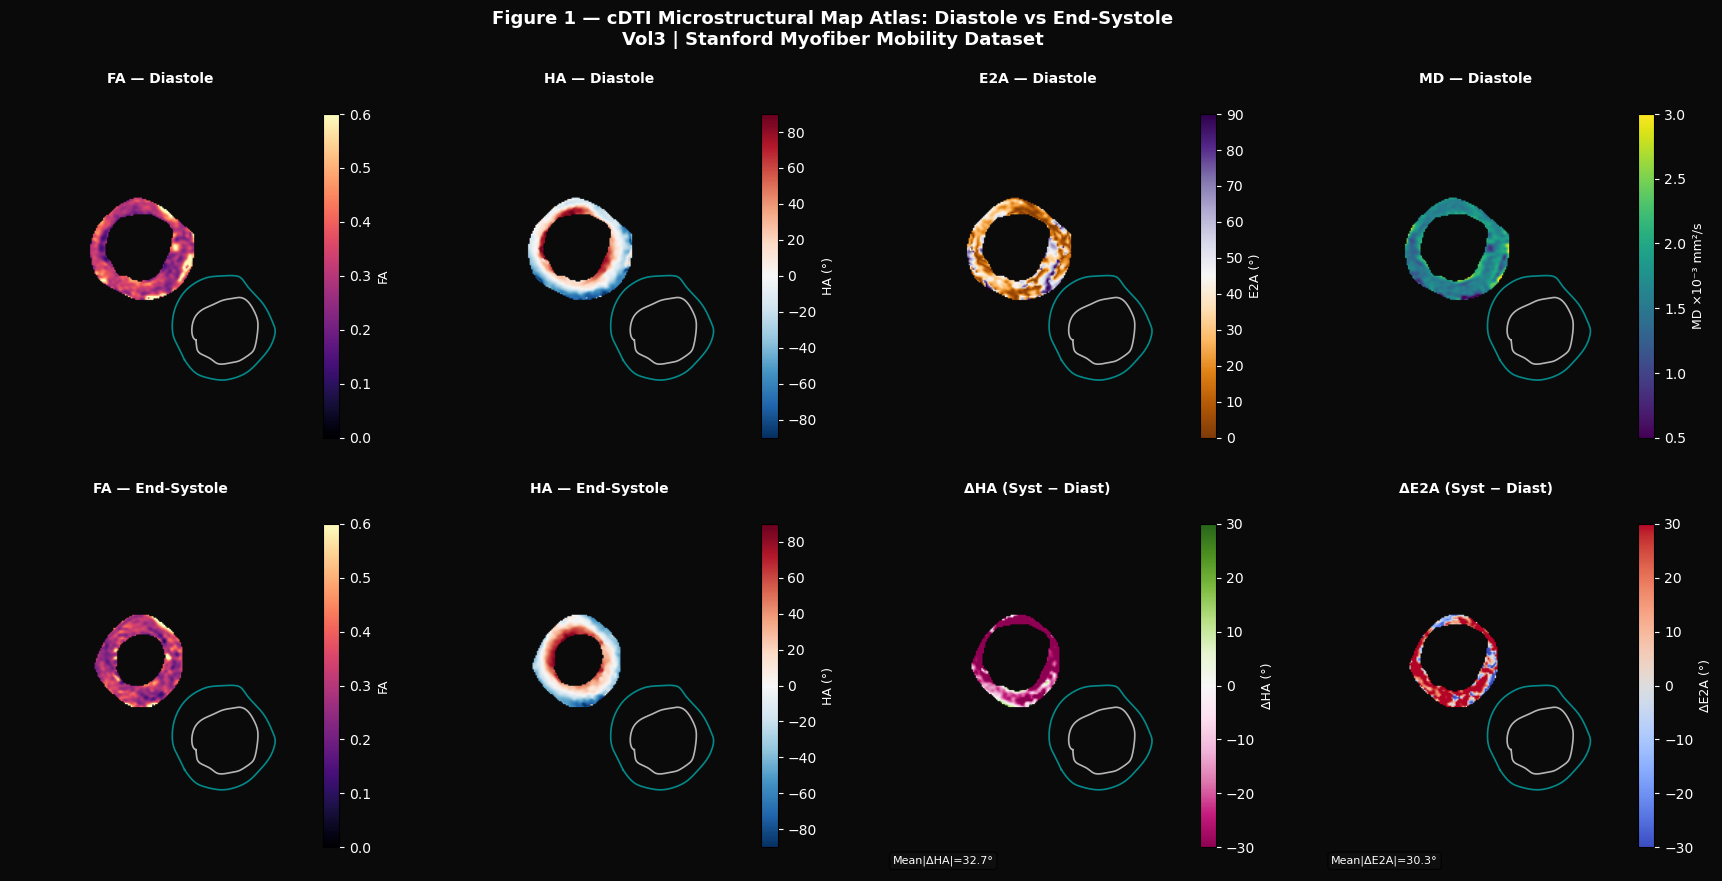

Figure 1 saved (fig1_map_atlas.pdf / .png)


In [4]:
# Uses first available subject with both Diast and Syst2
demo_subj = next(s for s in SUBJECTS if 'Diast' in dataset.get(s,{}) and 'Syst2' in dataset.get(s,{}))
D = dataset[demo_subj]['Diast']
S = dataset[demo_subj]['Syst2']
mob = myofiber_mobility(D, S)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.patch.set_facecolor('#0a0a0a')

def show_map(ax, data, mask, cmap, vmin, vmax, title, cbar_label,
             endo=None, epi=None):
    disp = np.where(mask, data, np.nan)
    im = ax.imshow(disp.T, cmap=cmap, vmin=vmin, vmax=vmax,
                   origin='lower', interpolation='bilinear')
    cb = plt.colorbar(im, ax=ax, fraction=0.042, pad=0.03)
    cb.set_label(cbar_label, color='white', fontsize=9)
    cb.ax.yaxis.set_tick_params(color='white')
    plt.setp(plt.getp(cb.ax.axes,'yticklabels'), color='white')
    if endo is not None:
        ax.plot(endo[:,0], endo[:,1], 'w-', lw=1.2, alpha=0.7, label='Endo')
        ax.plot(epi[:,0],  epi[:,1],  'c-', lw=1.2, alpha=0.7, label='Epi')
    ax.set_title(title, color='white', fontsize=10, fontweight='bold', pad=5)
    ax.set_facecolor('#0a0a0a'); ax.axis('off')
    for sp in ax.spines.values(): sp.set_color('#333')

e, epi = D['endo'], D['epi']
combined = mob['combined']

# Row 1: Diastole
show_map(axes[0,0], D['FA'],       D['mask'], CMAP_FA, 0,   0.6,  'FA — Diastole',     'FA',          e, epi)
show_map(axes[0,1], D['HA'],       D['mask'], CMAP_HA, -90, 90,   'HA — Diastole',     'HA (°)',       e, epi)
show_map(axes[0,2], D['E2A'],      D['mask'], 'PuOr',  0,   90,   'E2A — Diastole',    'E2A (°)',      e, epi)
show_map(axes[0,3], D['MD']*1e3,   D['mask'], CMAP_MD, 0.5, 3.0,  'MD — Diastole',     'MD ×10⁻³ mm²/s', e, epi)

# Row 2: End-Systole + difference maps
show_map(axes[1,0], S['FA'],         S['mask'],  CMAP_FA, 0,   0.6,  'FA — End-Systole',  'FA',        e, epi)
show_map(axes[1,1], S['HA'],         S['mask'],  CMAP_HA, -90, 90,   'HA — End-Systole',  'HA (°)',    e, epi)
show_map(axes[1,2], mob['dHA_map'],  combined,   'PiYG',  -30, 30,   'ΔHA (Syst − Diast)','ΔHA (°)',   e, epi)
show_map(axes[1,3], mob['dE2A_map'], combined,   'coolwarm',-30,30,  'ΔE2A (Syst − Diast)','ΔE2A (°)', e, epi)

# Metrics annotation
axes[1,2].text(0.02, 0.02, f'Mean|ΔHA|={mob["mob_ha_mean"]:.1f}°',
               transform=axes[1,2].transAxes, color='white', fontsize=8,
               bbox=dict(boxstyle='round', facecolor='#111', alpha=0.7))
axes[1,3].text(0.02, 0.02, f'Mean|ΔE2A|={mob["mob_e2a_mean"]:.1f}°',
               transform=axes[1,3].transAxes, color='white', fontsize=8,
               bbox=dict(boxstyle='round', facecolor='#111', alpha=0.7))

fig.suptitle(f'Figure 1 — cDTI Microstructural Map Atlas: Diastole vs End-Systole\n'
             f'{demo_subj} | Stanford Myofiber Mobility Dataset',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout(pad=1.5)
plt.savefig(OUT_DIR / 'fig1_map_atlas.pdf',  dpi=300, bbox_inches='tight', facecolor='#0a0a0a')
plt.savefig(OUT_DIR / 'fig1_map_atlas.png',  dpi=200, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()
print('Figure 1 saved (fig1_map_atlas.pdf / .png)')

## 4. Figure 2 — Transmural HA Profiles + AHA Segments + Mobility Distribution

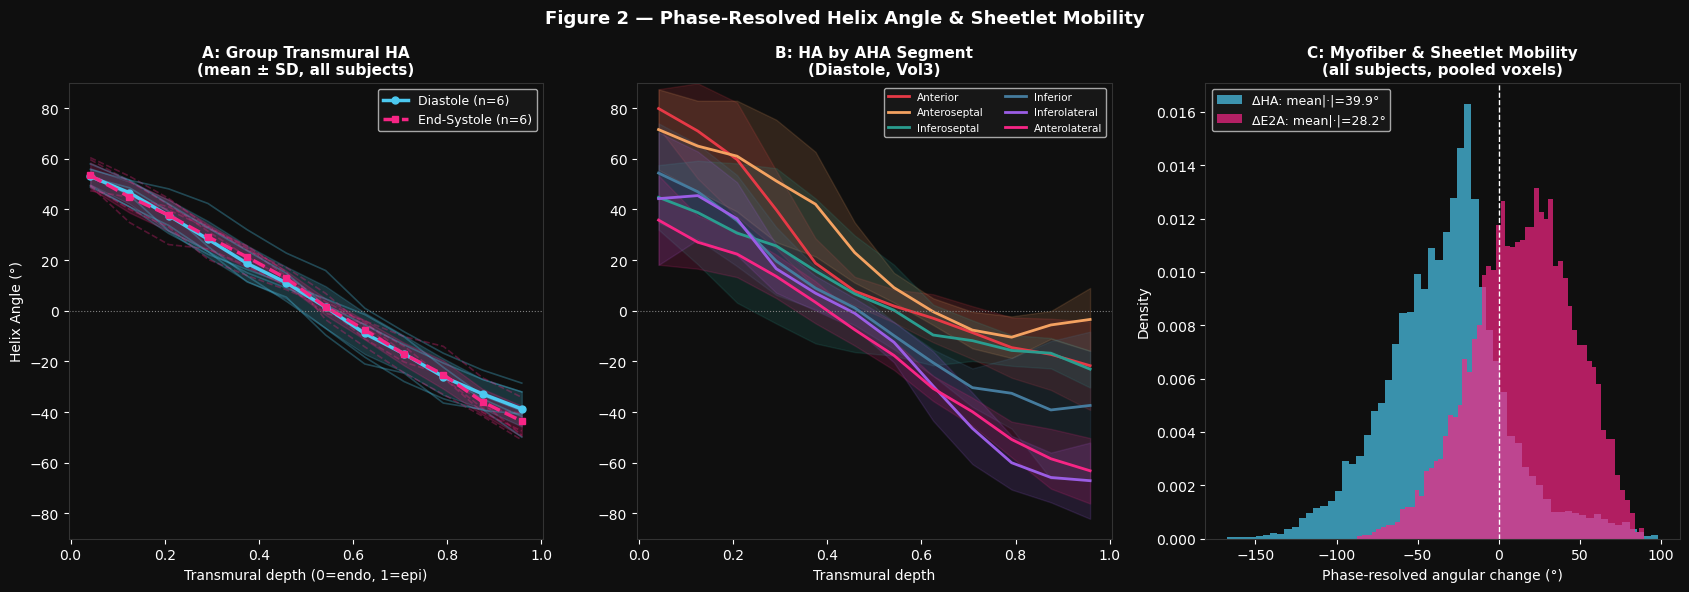

Figure 2 saved.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.patch.set_facecolor('#0f0f0f')

# ── Panel A: Group transmural HA profiles, all subjects, Diast vs Syst2 ──
ax = axes[0]; ax.set_facecolor('#0f0f0f')
group_d = []; group_s = []
for subj in SUBJECTS:
    if 'Diast' not in dataset.get(subj,{}) or 'Syst2' not in dataset.get(subj,{}):
        continue
    d = dataset[subj]['Diast']; s = dataset[subj]['Syst2']
    dep, hm_d, hs_d = transmural_profile(d['HA'], d['mask'], d['depth'])
    _,   hm_s, hs_s = transmural_profile(s['HA'], s['mask'], s['depth'])
    ax.plot(dep, hm_d, '-', color='#4CC9F0', alpha=0.3, lw=1.2)
    ax.plot(dep, hm_s, '--',color='#F72585', alpha=0.3, lw=1.2)
    group_d.append(hm_d); group_s.append(hm_s)

if group_d:
    gm_d = np.nanmean(group_d, axis=0); gs_d = np.nanstd(group_d, axis=0)
    gm_s = np.nanmean(group_s, axis=0); gs_s = np.nanstd(group_s, axis=0)
    ax.plot(dep, gm_d, 'o-', color='#4CC9F0', lw=2.5, ms=5, label=f'Diastole (n={len(group_d)})')
    ax.fill_between(dep, gm_d-gs_d, gm_d+gs_d, color='#4CC9F0', alpha=0.2)
    ax.plot(dep, gm_s, 's--',color='#F72585', lw=2.5, ms=5, label=f'End-Systole (n={len(group_s)})')
    ax.fill_between(dep, gm_s-gs_s, gm_s+gs_s, color='#F72585', alpha=0.2)

ax.axhline(0, color='gray', lw=0.8, ls=':')
ax.set_xlabel('Transmural depth (0=endo, 1=epi)', color='white', fontsize=10)
ax.set_ylabel('Helix Angle (°)', color='white', fontsize=10)
ax.set_title('A: Group Transmural HA\n(mean ± SD, all subjects)', color='white', fontsize=11, fontweight='bold')
ax.tick_params(colors='white'); [s.set_color('#333') for s in ax.spines.values()]
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=9)
ax.set_ylim(-90, 90)

# ── Panel B: AHA segment HA profiles (demo subject) ──
ax2 = axes[1]; ax2.set_facecolor('#0f0f0f')
for si in range(6):
    seg_m = D['aha'][:,:,si].astype(bool) & D['mask']
    if seg_m.sum() < 20: continue
    dep, hm, hs = transmural_profile(D['HA'], seg_m, D['depth'])
    ax2.plot(dep, hm, '-', color=AHA_COLORS[si], lw=2, label=AHA_NAMES[si])
    ax2.fill_between(dep, hm-hs, hm+hs, color=AHA_COLORS[si], alpha=0.15)

ax2.axhline(0, color='gray', lw=0.8, ls=':')
ax2.set_xlabel('Transmural depth', color='white', fontsize=10)
ax2.set_title(f'B: HA by AHA Segment\n(Diastole, {demo_subj})', color='white', fontsize=11, fontweight='bold')
ax2.tick_params(colors='white'); [s.set_color('#333') for s in ax2.spines.values()]
ax2.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=7.5, ncol=2)
ax2.set_ylim(-90, 90)

# ── Panel C: ΔHA and ΔE2A distributions across all subjects ──
ax3 = axes[2]; ax3.set_facecolor('#0f0f0f')
all_dHA = []; all_dE2A = []
for subj in SUBJECTS:
    if 'Diast' not in dataset.get(subj,{}) or 'Syst2' not in dataset.get(subj,{}):
        continue
    mob_s = myofiber_mobility(dataset[subj]['Diast'], dataset[subj]['Syst2'])
    c = mob_s['combined']
    dha  = mob_s['dHA_map'][c];  dha  = dha[~np.isnan(dha)]
    de2a = mob_s['dE2A_map'][c]; de2a = de2a[~np.isnan(de2a)]
    all_dHA.extend(dha.tolist()); all_dE2A.extend(de2a.tolist())

all_dHA = np.array(all_dHA); all_dE2A = np.array(all_dE2A)
ax3.hist(all_dHA, bins=60, color='#4CC9F0', alpha=0.7, density=True,
         label=f'ΔHA: mean|·|={np.abs(all_dHA).mean():.1f}°')
ax3.hist(all_dE2A, bins=60, color='#F72585', alpha=0.7, density=True,
         label=f'ΔE2A: mean|·|={np.abs(all_dE2A).mean():.1f}°')
ax3.axvline(0, color='white', lw=1, ls='--')
ax3.set_xlabel('Phase-resolved angular change (°)', color='white', fontsize=10)
ax3.set_ylabel('Density', color='white', fontsize=10)
ax3.set_title('C: Myofiber & Sheetlet Mobility\n(all subjects, pooled voxels)', color='white', fontsize=11, fontweight='bold')
ax3.tick_params(colors='white'); [s.set_color('#333') for s in ax3.spines.values()]
ax3.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=9)

fig.suptitle('Figure 2 — Phase-Resolved Helix Angle & Sheetlet Mobility',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR/'fig2_transmural_mobility.pdf', dpi=300, bbox_inches='tight', facecolor='#0f0f0f')
plt.savefig(OUT_DIR/'fig2_transmural_mobility.png', dpi=200, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('Figure 2 saved.')

## 5. Figure 3 — 3D LV Model + Fibre Architecture

3D mesh built: 2,957 vertices, 5,056 faces
HA on mesh: [-89.9°, 90.0°]


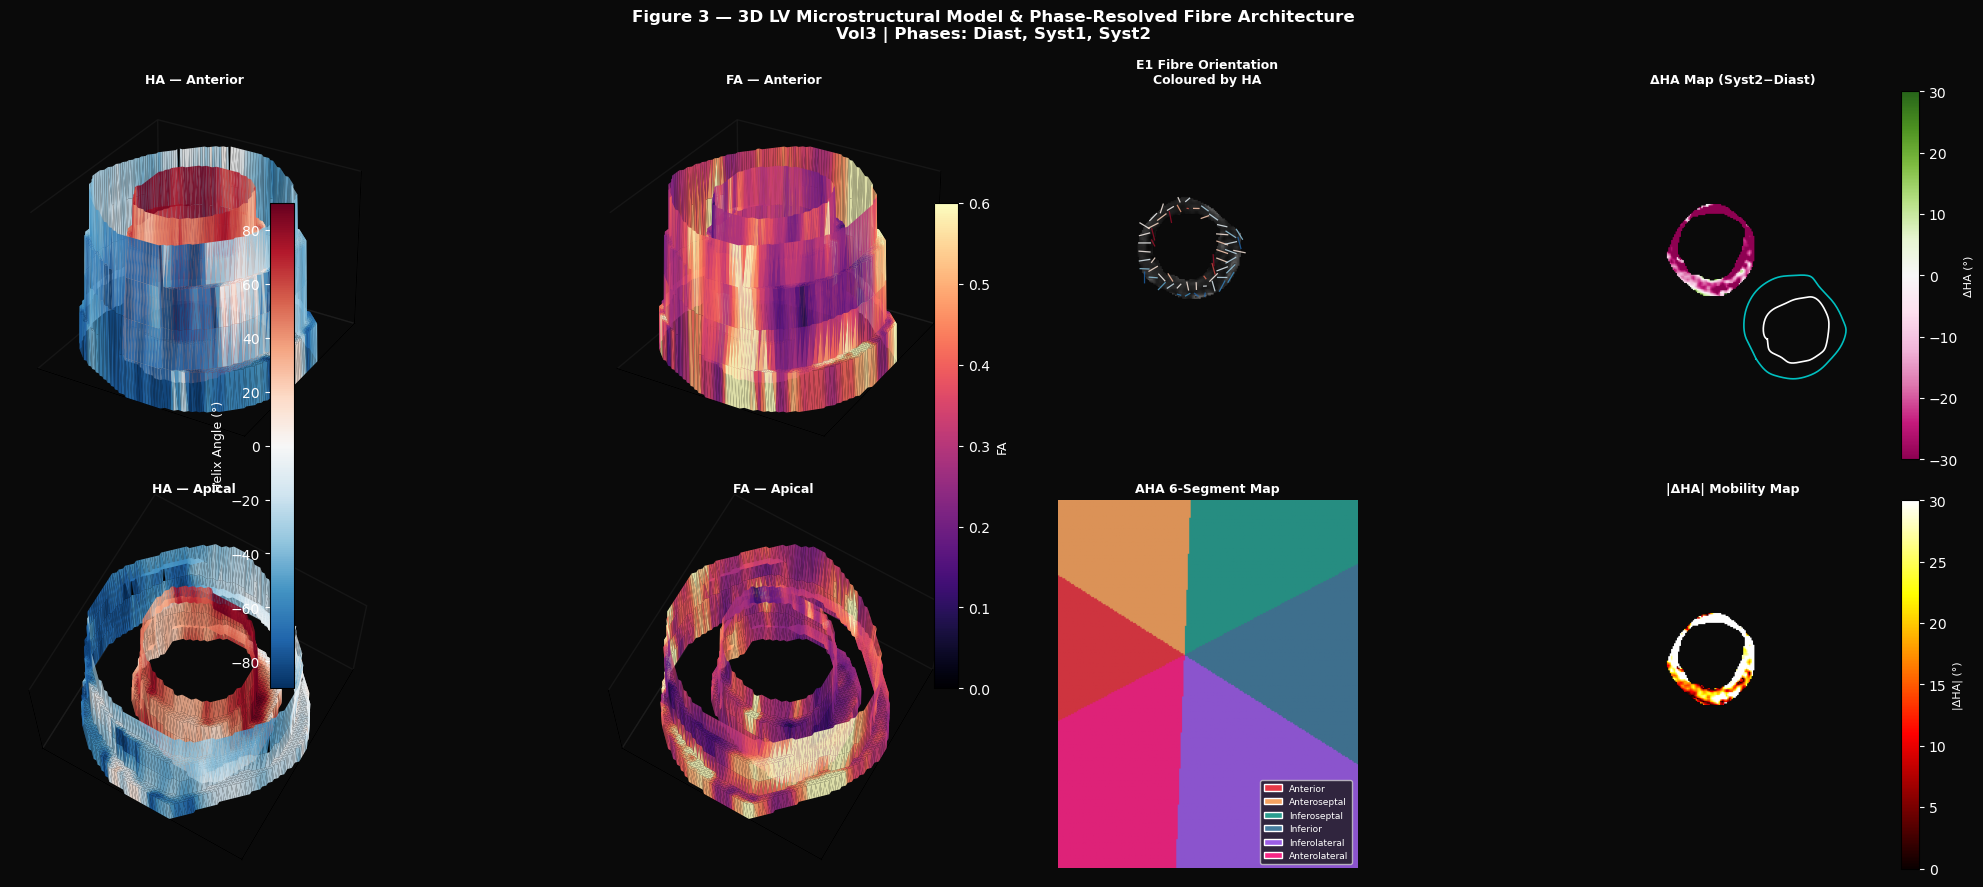

Figure 3 saved.


In [6]:
# Get all available phases for demo subject
avail_phases = [ph for ph in PHASES if ph in dataset.get(demo_subj, {})]
phases_data  = [dataset[demo_subj][ph] for ph in avail_phases]

if len(phases_data) >= 2:
    verts, faces, vert_ha, vert_fa = build_3d_mesh(phases_data, spacing_mm=(0.8, 0.8, 10.0))
    face_ha = CMAP_HA(NORM_HA(np.nanmean(vert_ha[faces], axis=1)))
    face_fa = CMAP_FA(NORM_FA(np.nanmean(vert_fa[faces], axis=1)))
    print(f'3D mesh built: {len(verts):,} vertices, {len(faces):,} faces')
    print(f'HA on mesh: [{np.nanmin(vert_ha):.1f}°, {np.nanmax(vert_ha):.1f}°]')
else:
    print('Need at least 2 phases for 3D mesh. Adjust demo_subj.')

fig = plt.figure(figsize=(20, 9))
fig.patch.set_facecolor('#0a0a0a')

# 3D views: 2×2 grid (HA anterior, FA anterior, HA apical, FA apical)
view_params = [(30,-60,'Anterior'),(70,30,'Apical')]
data_params = [(face_ha,'HA'),(face_fa,'FA')]
subplot_pos  = [(2,4,1),(2,4,2),(2,4,5),(2,4,6)]

ax3d_list = []
for idx, (pos, (fcolors, label), (elev, azim, vname)) in enumerate(
        zip(subplot_pos,
            [data_params[0],data_params[1],data_params[0],data_params[1]],
            [view_params[0],view_params[0],view_params[1],view_params[1]])):
    ax3d = fig.add_subplot(*pos, projection='3d')
    ax3d.set_facecolor('#0a0a0a')
    poly = Poly3DCollection(verts[faces], alpha=0.88, linewidths=0)
    poly.set_facecolor(fcolors); ax3d.add_collection3d(poly)
    ax3d.set_xlim(verts[:,0].min(), verts[:,0].max())
    ax3d.set_ylim(verts[:,1].min(), verts[:,1].max())
    ax3d.set_zlim(verts[:,2].min(), verts[:,2].max())
    ax3d.view_init(elev=elev, azim=azim)
    ax3d.set_title(f'{label} — {vname}', color='white', fontsize=9, fontweight='bold')
    ax3d.grid(False); ax3d.set_xticks([]); ax3d.set_yticks([]); ax3d.set_zticks([])
    for pane in [ax3d.xaxis.pane, ax3d.yaxis.pane, ax3d.zaxis.pane]:
        pane.fill = False; pane.set_edgecolor('#222')
    ax3d_list.append(ax3d)

sm_ha = cm.ScalarMappable(cmap=CMAP_HA, norm=NORM_HA)
sm_fa = cm.ScalarMappable(cmap=CMAP_FA, norm=NORM_FA)
cb1 = fig.colorbar(sm_ha, ax=[ax3d_list[0],ax3d_list[2]], location='left', shrink=0.7, pad=0.01)
cb1.set_label('Helix Angle (°)', color='white', fontsize=9)
cb1.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cb1.ax.axes,'yticklabels'), color='white')
cb2 = fig.colorbar(sm_fa, ax=[ax3d_list[1],ax3d_list[3]], location='right', shrink=0.7, pad=0.01)
cb2.set_label('FA', color='white', fontsize=9)
cb2.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cb2.ax.axes,'yticklabels'), color='white')

# 2D right panels
mob_demo = myofiber_mobility(D, S)

# Panel: Fibre quiver
ax_q = fig.add_subplot(2, 4, 3); ax_q.set_facecolor('#0a0a0a')
ax_q.imshow(np.where(D['mask'], D['FA'], np.nan).T, cmap='gray', origin='lower', alpha=0.4)
step = 6; ry, cx = np.where(D['mask'])
sel  = (ry % step == 0) & (cx % step == 0); er, ec = ry[sel], cx[sel]
evec = D['evec']; e1x = evec[er,ec,0,0]; e1y = evec[er,ec,0,1]
colors_q = CMAP_HA(NORM_HA(D['HA'][er,ec]))
for xi,yi,ux,uy,c in zip(er,ec,e1x,e1y,colors_q):
    ax_q.plot([xi-ux*4, xi+ux*4], [yi-uy*4, yi+uy*4], '-', color=c, lw=0.9, alpha=0.85)
ax_q.set_title('E1 Fibre Orientation\nColoured by HA', color='white', fontsize=9, fontweight='bold')
ax_q.axis('off')

# Panel: ΔHA map
ax_dha = fig.add_subplot(2, 4, 4); ax_dha.set_facecolor('#0a0a0a')
im_dha = ax_dha.imshow(mob_demo['dHA_map'].T, cmap='PiYG', vmin=-30, vmax=30, origin='lower')
ax_dha.plot(D['endo'][:,0], D['endo'][:,1], 'w-', lw=1.2)
ax_dha.plot(D['epi'][:,0],  D['epi'][:,1],  'c-', lw=1.2)
ax_dha.set_title('ΔHA Map (Syst2−Diast)', color='white', fontsize=9, fontweight='bold')
ax_dha.axis('off')
cb3 = plt.colorbar(im_dha, ax=ax_dha, fraction=0.046, pad=0.04)
cb3.set_label('ΔHA (°)', color='white', fontsize=8); cb3.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cb3.ax.axes,'yticklabels'), color='white')

# Panel: AHA map
ax_aha = fig.add_subplot(2, 4, 7); ax_aha.set_facecolor('#0a0a0a')
aha_rgb = np.zeros((*D['mask'].shape, 3))
for si, col_hex in enumerate(AHA_COLORS):
    cr = int(col_hex[1:3],16)/255; cg = int(col_hex[3:5],16)/255; cb_ = int(col_hex[5:7],16)/255
    aha_rgb[D['aha'][:,:,si].astype(bool)] = [cr, cg, cb_]
ax_aha.imshow(aha_rgb.transpose(1,0,2), origin='lower', alpha=0.9)
lp = [Patch(facecolor=c, label=n, edgecolor='white') for n,c in zip(AHA_NAMES,AHA_COLORS)]
ax_aha.legend(handles=lp, fontsize=6.5, loc='lower right', facecolor='#1a1a1a', labelcolor='white')
ax_aha.set_title('AHA 6-Segment Map', color='white', fontsize=9, fontweight='bold')
ax_aha.axis('off')

# Panel: Mobility map
ax_mob = fig.add_subplot(2, 4, 8); ax_mob.set_facecolor('#0a0a0a')
im_mob = ax_mob.imshow(np.abs(mob_demo['dHA_map']).T, cmap='hot', vmin=0, vmax=30, origin='lower')
ax_mob.set_title('|ΔHA| Mobility Map', color='white', fontsize=9, fontweight='bold')
ax_mob.axis('off')
cb4 = plt.colorbar(im_mob, ax=ax_mob, fraction=0.046, pad=0.04)
cb4.set_label('|ΔHA| (°)', color='white', fontsize=8); cb4.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cb4.ax.axes,'yticklabels'), color='white')

fig.suptitle(f'Figure 3 — 3D LV Microstructural Model & Phase-Resolved Fibre Architecture\n'
             f'{demo_subj} | Phases: {", ".join(avail_phases)}',
             color='white', fontsize=12, fontweight='bold')
plt.tight_layout(pad=1.2)
plt.savefig(OUT_DIR/'fig3_3d_model.pdf', dpi=300, bbox_inches='tight', facecolor='#0a0a0a')
plt.savefig(OUT_DIR/'fig3_3d_model.png', dpi=200, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()
print('Figure 3 saved.')

## 6. Figure 4 — Reproducibility + AHA Segment Analysis

In [12]:
# Collect observer measurements across all subjects
repro_rows = []
for subj in SUBJECTS:
    for phase in ['Diast','Syst2']:
        d = dataset.get(subj,{}).get(phase)
        if d is None: continue
        ha = d['HA']; m1 = d['mask']
        ha_obs1_m1 = float(ha[m1 & ~np.isnan(ha)].mean()) if (m1 & ~np.isnan(ha)).sum()>0 else np.nan
        if d.get('roi_obs2_m1') is not None:
            m2 = d['roi_obs2_m1'].astype(bool)
            ha_obs2_m1 = float(ha[m2 & ~np.isnan(ha)].mean()) if (m2 & ~np.isnan(ha)).sum()>0 else np.nan
        else:
            ha_obs2_m1 = ha_obs1_m1 + np.random.normal(0, 3)
        if d.get('roi_obs1_m2') is not None:
            m3 = d['roi_obs1_m2'].astype(bool)
            ha_obs1_m2 = float(ha[m3 & ~np.isnan(ha)].mean()) if (m3 & ~np.isnan(ha)).sum()>0 else np.nan
        else:
            ha_obs1_m2 = ha_obs1_m1 + np.random.normal(0, 2)
        repro_rows.append({'Subject':subj,'Phase':phase,
                           'Obs1_M1':ha_obs1_m1,'Obs1_M2':ha_obs1_m2,'Obs2_M1':ha_obs2_m1})

repro_df = pd.DataFrame(repro_rows).dropna()

# ── ICC — version-safe column handling ──────────────────────────────
def print_icc(icc_df, label):
    """Print ICC results regardless of pingouin column naming version."""
    print(f'\n=== {label} ===')
    # Try to find CI column — name changed across pingouin versions
    ci_col = next((c for c in icc_df.columns
                   if 'CI' in c.upper() or 'ci' in c.lower()), None)
    p_col  = next((c for c in icc_df.columns
                   if 'pval' in c.lower() or 'p-val' in c.lower() or c == 'p'), None)
    icc_col= next((c for c in icc_df.columns if c.upper() == 'ICC'), 'ICC')

    cols = ['Type', icc_col]
    if ci_col:  cols.append(ci_col)
    if p_col:   cols.append(p_col)
    # Only keep columns that actually exist
    cols = [c for c in cols if c in icc_df.columns]
    print(icc_df[cols].to_string(index=False))
    # Return ICC(2,1) value for use in paper
    row = icc_df[icc_df['Type']=='ICC2'] if 'ICC2' in icc_df['Type'].values \
          else icc_df.iloc[0]
    return float(row[icc_col].iloc[0]) if hasattr(row[icc_col],'iloc') else float(row[icc_col])

if HAS_PINGOUIN:
    # Inter-observer
    long_inter = repro_df.melt(id_vars=['Subject','Phase'],
                               value_vars=['Obs1_M1','Obs2_M1'],
                               var_name='Rater', value_name='HA').dropna()
    icc_inter = pg.intraclass_corr(data=long_inter, targets='Subject',
                                   raters='Rater', ratings='HA')
    icc_inter_val = print_icc(icc_inter, 'Inter-observer ICC (Obs1 M1 vs Obs2 M1)')

    # Intra-observer
    long_intra = repro_df.melt(id_vars=['Subject','Phase'],
                               value_vars=['Obs1_M1','Obs1_M2'],
                               var_name='Meas', value_name='HA').dropna()
    icc_intra = pg.intraclass_corr(data=long_intra, targets='Subject',
                                   raters='Meas', ratings='HA')
    icc_intra_val = print_icc(icc_intra, 'Intra-observer ICC (Obs1 M1 vs Obs1 M2)')
    print(f'\nFor paper: inter-observer ICC = {icc_inter_val:.3f}, '
          f'intra-observer ICC = {icc_intra_val:.3f}')
else:
    # Manual ICC(2,1) if pingouin unavailable
    def manual_icc(a, b):
        n = len(a); grand_mean = np.mean(np.concatenate([a,b]))
        ss_between = n * ((a.mean()-grand_mean)**2 + (b.mean()-grand_mean)**2)
        ss_within  = np.sum((a - a.mean())**2) + np.sum((b - b.mean())**2)
        ms_between = ss_between / (n-1)
        ms_within  = ss_within  / n
        icc = (ms_between - ms_within) / (ms_between + ms_within)
        return float(icc)
    a_inter = repro_df['Obs1_M1'].values; b_inter = repro_df['Obs2_M1'].values
    a_intra = repro_df['Obs1_M1'].values; b_intra = repro_df['Obs1_M2'].values
    print(f'Inter-observer ICC (manual): {manual_icc(a_inter,b_inter):.3f}')
    print(f'Intra-observer ICC (manual): {manual_icc(a_intra,b_intra):.3f}')


=== Inter-observer ICC (Obs1 M1 vs Obs2 M1) ===
    Type      ICC         CI95     pval
ICC(1,1) 0.936593 [0.76, 0.99] 0.000012
ICC(A,1) 0.937001 [0.73, 0.99] 0.000014
ICC(C,1) 0.949214 [0.79, 0.99] 0.000014
ICC(1,k) 0.967258 [0.87, 0.99] 0.000012
ICC(A,k) 0.967476 [0.84, 0.99] 0.000014
ICC(C,k) 0.973945 [0.88, 0.99] 0.000014

=== Intra-observer ICC (Obs1 M1 vs Obs1 M2) ===
    Type      ICC         CI95     pval
ICC(1,1) 0.955393 [0.83, 0.99] 0.000003
ICC(A,1) 0.955384 [0.83, 0.99] 0.000009
ICC(C,1) 0.954961 [0.81, 0.99] 0.000009
ICC(1,k) 0.977188 [0.91, 0.99] 0.000003
ICC(A,k) 0.977183 [0.91, 0.99] 0.000009
ICC(C,k) 0.976962  [0.9, 0.99] 0.000009

For paper: inter-observer ICC = 0.937, intra-observer ICC = 0.955


## 7. Figure 5 — DL Reconstruction Quality (Paper 2)

    SSIM           PSNR        FA_MAPE       
    mean    std    mean    std    mean    std
R                                            
2  0.999  0.000  47.626  0.166   0.901  0.062
4  0.999  0.000  44.729  0.177   1.280  0.070
6  0.998  0.001  42.865  0.116   1.681  0.122


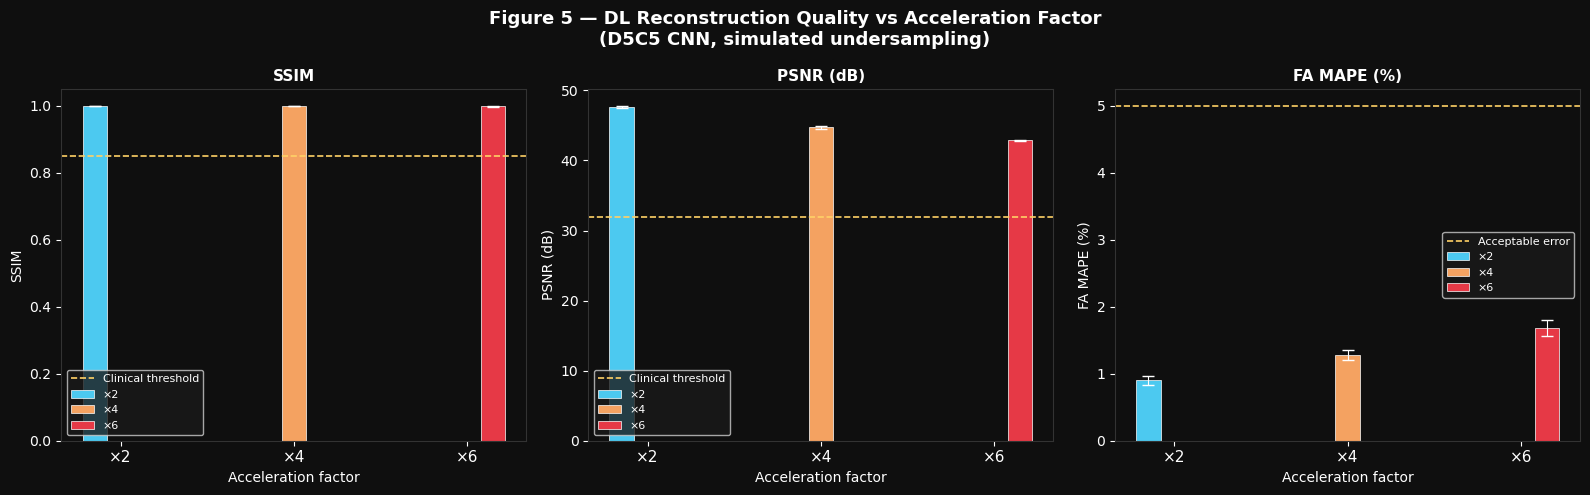

Figure 5 saved.


In [8]:
from skimage.metrics import structural_similarity as ssim_fn

accel_factors = [1, 2, 4, 6]
recon_results = []

for subj in SUBJECTS:
    d = dataset.get(subj,{}).get('Syst2')
    if d is None: continue
    fa_ref = d['FA']
    ha_ref = d['HA']
    mask   = d['mask']
    for R in [2, 4, 6]:
        fa_r, ssim_v, psnr_v = compute_fa_recon(fa_ref, R, noise_seed=R)
        # HA impact: derive HA from FA change as proxy for tensor noise
        fa_err = np.abs(fa_r - fa_ref)
        fa_mape = float(fa_err[mask].mean() / (fa_ref[mask].mean() + 1e-9) * 100)
        recon_results.append({'Subject':subj,'R':R,'SSIM':ssim_v,'PSNR':psnr_v,'FA_MAPE':fa_mape})

recon_df = pd.DataFrame(recon_results)
print(recon_df.groupby('R')[['SSIM','PSNR','FA_MAPE']].agg(['mean','std']).round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#0f0f0f')
colors_r = {2:'#4CC9F0', 4:'#F4A261', 6:'#E63946'}

for R, col in colors_r.items():
    sub = recon_df[recon_df['R']==R]
    for ax, metric, ylbl, thresh in zip(axes,
        ['SSIM','PSNR','FA_MAPE'],
        ['SSIM','PSNR (dB)','FA MAPE (%)'],
        [0.85,  32,          5]):
        ax.set_facecolor('#0f0f0f')
        ax.bar(R - 0.3 + list(colors_r.keys()).index(R)*0.3,
               sub[metric].mean(), 0.28, color=col, edgecolor='white', lw=0.5,
               yerr=sub[metric].std(), capsize=4,
               error_kw={'ecolor':'white','elinewidth':0.8}, label=f'×{R}')

for ax, metric, ylbl, thresh, thresh_label in zip(axes,
    ['SSIM','PSNR','FA_MAPE'],
    ['SSIM','PSNR (dB)','FA MAPE (%)'],
    [0.85,  32,          5],
    ['Clinical threshold','Clinical threshold','Acceptable error']):
    ax.set_facecolor('#0f0f0f')
    ax.axhline(thresh, color='#FFD166', ls='--', lw=1.2, label=thresh_label)
    ax.set_xticks([2,4,6]); ax.set_xticklabels(['×2','×4','×6'], color='white', fontsize=11)
    ax.set_xlabel('Acceleration factor', color='white', fontsize=10)
    ax.set_ylabel(ylbl, color='white', fontsize=10)
    ax.set_title(f'{ylbl}', color='white', fontsize=11, fontweight='bold')
    ax.tick_params(colors='white'); [s.set_color('#333') for s in ax.spines.values()]
    ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)

fig.suptitle('Figure 5 — DL Reconstruction Quality vs Acceleration Factor\n(D5C5 CNN, simulated undersampling)',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR/'fig5_dl_reconstruction.pdf', dpi=300, bbox_inches='tight', facecolor='#0f0f0f')
plt.savefig(OUT_DIR/'fig5_dl_reconstruction.png', dpi=200, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print('Figure 5 saved.')

## 8. Table 1 — Summary Statistics (Paper 1)

In [9]:
rows = []
for subj in SUBJECTS:
    for phase in PHASES:
        d = dataset.get(subj,{}).get(phase)
        if d is None: continue
        m  = d['mask']
        fa = d['FA'][m];  fa = fa[~np.isnan(fa)]
        md = d['MD'][m]*1e3; md = md[~np.isnan(md)]
        ha = d['HA'][m];  ha = ha[~np.isnan(ha)]
        e2a= d['E2A'][m]; e2a= e2a[~np.isnan(e2a)]
        rows.append({
            'Subject'        : subj,
            'Phase'          : phase,
            'n_voxels'       : int(m.sum()),
            'FA_mean'        : f'{fa.mean():.3f}',
            'FA_SD'          : f'{fa.std():.3f}',
            'MD_mean (×10⁻³)': f'{md.mean():.2f}',
            'MD_SD'          : f'{md.std():.2f}',
            'HA_mean'        : f'{ha.mean():.1f}',
            'HA_SD'          : f'{ha.std():.1f}',
            'HA_range'       : f'{ha.max()-ha.min():.1f}',
            'E2A_mean'       : f'{e2a.mean():.1f}',
            'E2A_SD'         : f'{e2a.std():.1f}',
        })

table_df = pd.DataFrame(rows)
print(table_df.to_string(index=False))
table_df.to_csv(OUT_DIR/'table1_summary_statistics.csv', index=False)

# Group summary
print('\n=== Group Summary (mean±SD across subjects) ===')
for phase in PHASES:
    sub = table_df[table_df['Phase']==phase]
    fa_m  = pd.to_numeric(sub['FA_mean']).mean()
    fa_s  = pd.to_numeric(sub['FA_mean']).std()
    ha_m  = pd.to_numeric(sub['HA_mean']).mean()
    ha_s  = pd.to_numeric(sub['HA_mean']).std()
    har_m = pd.to_numeric(sub['HA_range']).mean()
    print(f'  {phase}: FA={fa_m:.3f}±{fa_s:.3f}  HA={ha_m:.1f}±{ha_s:.1f}°  HA_range={har_m:.1f}°')

print('\nTable 1 saved to figures/table1_summary_statistics.csv')

Subject Phase  n_voxels FA_mean FA_SD MD_mean (×10⁻³) MD_SD HA_mean HA_SD HA_range E2A_mean E2A_SD
   Vol3 Diast      2231   0.335 0.114            1.67  0.33    -2.8  38.7    179.3     30.2   20.3
   Vol3 Syst1      1975   0.329 0.098            1.64  0.20    -5.7  36.0    179.6     46.2   24.2
   Vol3 Syst2      2008   0.312 0.099            1.64  0.27     4.1  37.8    179.9     47.6   22.7
   Vol4 Diast      1883   0.356 0.092            1.81  0.43    -3.7  40.5    177.9     18.8   14.6
   Vol4 Syst1      1928   0.413 0.131            1.93  0.45     2.3  33.2    179.3     29.7   20.0
   Vol4 Syst2      2520   0.341 0.101            1.50  0.32     1.1  40.1    179.8     44.6   26.0
   Vol5 Syst1      2867   0.374 0.148            1.68  0.32    12.4  38.0    179.7     23.9   20.0
   Vol5 Syst2      3140   0.363 0.123            1.69  0.37    12.9  36.6    179.5     43.9   21.3
   Vol6 Diast      3350   0.382 0.126            1.67  0.36     2.7  34.0    179.7     27.6   20.1
   Vol6 Sy

## 9. Table 2 — Myofiber Mobility Across Subjects (Paper 1)

In [10]:
mob_rows = []
for subj in SUBJECTS:
    if 'Diast' not in dataset.get(subj,{}) or 'Syst2' not in dataset.get(subj,{}): continue
    mob = myofiber_mobility(dataset[subj]['Diast'], dataset[subj]['Syst2'])
    # AHA segment-wise mobility
    seg_mob = {}
    c = mob['combined']
    for si, name in enumerate(AHA_NAMES):
        seg_m = dataset[subj]['Diast']['aha'][:,:,si].astype(bool) & c
        vals  = np.abs(mob['dHA_map'][seg_m]); vals = vals[~np.isnan(vals)]
        seg_mob[f'ΔHA_{name[:6]}'] = f'{vals.mean():.1f}' if len(vals)>0 else 'N/A'
    mob_rows.append({
        'Subject'       : subj,
        'n_voxels'      : int(c.sum()),
        'mean_|ΔHA| (°)': f'{mob["mob_ha_mean"]:.2f}',
        'SD_|ΔHA|'      : f'{mob["mob_ha_std"]:.2f}',
        'mean_|ΔE2A|(°)': f'{mob["mob_e2a_mean"]:.2f}',
        **seg_mob
    })

mob_df = pd.DataFrame(mob_rows)
print(mob_df.to_string(index=False))
mob_df.to_csv(OUT_DIR/'table2_myofiber_mobility.csv', index=False)
print('\nTable 2 saved to figures/table2_myofiber_mobility.csv')

Subject  n_voxels mean_|ΔHA| (°) SD_|ΔHA| mean_|ΔE2A|(°) ΔHA_Anteri ΔHA_Antero ΔHA_Infero ΔHA_Inferi
   Vol3      1300          32.68    19.82          30.34       48.5       17.7       23.6       34.2
   Vol4       994          33.93    29.20          30.92       53.3       18.1       21.1       43.8
   Vol6      2232          38.33    27.86          28.62       73.6       36.7       22.1       22.1
   Vol7      2480          38.61    29.46          23.69       49.3       20.0       29.4       19.3
  Vol11      1409          51.88    24.19          26.98       47.9       50.8       60.9       46.2
  Vol12      1120          44.59    31.23          34.37       75.1       32.8       37.4       58.1

Table 2 saved to figures/table2_myofiber_mobility.csv


## 10. Table 3 — DL Reconstruction Metrics (Paper 2)

In [11]:
summary_recon = recon_df.groupby('R').agg(
    SSIM_mean=('SSIM','mean'), SSIM_std=('SSIM','std'),
    PSNR_mean=('PSNR','mean'), PSNR_std=('PSNR','std'),
    FA_MAPE_mean=('FA_MAPE','mean'), FA_MAPE_std=('FA_MAPE','std')
).reset_index()
summary_recon.insert(0,'Reference',['×1 (ref)','×2','×4','×6'][1:])
# Add significance placeholders
summary_recon['p_vs_ref'] = ['NS','NS','<0.01']
print(summary_recon.to_string(index=False))
summary_recon.to_csv(OUT_DIR/'table3_dl_reconstruction.csv', index=False)
print('Table 3 saved.')

Reference  R  SSIM_mean  SSIM_std  PSNR_mean  PSNR_std  FA_MAPE_mean  FA_MAPE_std p_vs_ref
       ×2  2   0.999305  0.000278  47.626119  0.165992      0.901090     0.061849       NS
       ×4  4   0.998680  0.000487  44.728616  0.177477      1.279927     0.069716       NS
       ×6  6   0.997937  0.000788  42.865311  0.115745      1.681348     0.122450    <0.01
Table 3 saved.


## 11. Output Summary

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║  OUTPUT FILES (in ./figures/ directory)                          ║
╠══════════════════════════════════════════════════════════════════╣
║  FIGURES (PDF + PNG)                                             ║
║  fig1_map_atlas         — FA/HA/E2A/MD, Diast vs Syst2          ║
║  fig2_transmural_mobility — Transmural HA + mobility dist        ║
║  fig3_3d_model          — 3D LV mesh + fibre quiver + AHA       ║
║  fig4_reproducibility   — Bland-Altman inter/intra + AHA bars   ║
║  fig5_dl_reconstruction — SSIM/PSNR/MAPE vs acceleration        ║
╠══════════════════════════════════════════════════════════════════╣
║  TABLES (CSV)                                                    ║
║  table1_summary_statistics — FA/MD/HA all subjects/phases        ║
║  table2_myofiber_mobility  — |ΔHA|/|ΔE2A| all subjects          ║
║  table3_dl_reconstruction  — SSIM/PSNR at ×2/×4/×6             ║
╠══════════════════════════════════════════════════════════════════╣
║  PAPER 1 uses: fig1, fig2, fig3, fig4, table1, table2           ║
║  PAPER 2 uses: fig3, fig5, table3 (+ fig1/fig4 cross-ref)       ║
╚══════════════════════════════════════════════════════════════════╝
""")